<a href="https://colab.research.google.com/github/Apekshya175/AI-ML/blob/main/Worksheet2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercise- Building a Softmax Regression for MNIST Digit
Classification:

1. Starter Code- Softmax Function:

In [ ]:
# Softmax Function
import numpy as np
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
    z (numpy.ndarray): Logits (raw scores) of shape (m, n), where
    - m is the number of samples
    - n is the number of classes.

    Returns:
    numpy.ndarray: Softmax probability matrix of shape (m, n), where
    each row sums to 1 and represents the probability distribution over classes.

    Notes:
    - The input to softmax is typically computed as: z = XW + b.
    - Uses numerical stabilization by subtracting the max value per row.
    """
    adjust_z = z - np.max(z, axis = 1, keepdims = True)
    exp_z = np.exp(adjust_z)
    softmax_probabilites = exp_z/np.sum(exp_z, axis = 1, keepdims = True)
    return softmax_probabilites


In [ ]:
# Softmax Test Function
z_test=np.array([[2.0,1.0,0.1],[1.0, 1.0,1.0]])
softmax_output =softmax(z_test)
row_sums=np.sum(softmax_output,axis=1)
assert np.allclose(row_sums,1),f"Test failed:Rowsumsare{row_sums}"
print("Softmax function passed the test case!")

Softmax function passed the test case!


2. StarterCode-PredictionFunction:

In [ ]:
#Prediction Function
def predict_softmax(X,W,b):
 """
 Predicttheclasslabelsforasetofsamplesusingthetrainedsoftmaxmodel.
 Parameters:
 X (numpy.ndarray):Featurematrixofshape(n,d),wherenisthenumberofsamplesand disthe
 numberoffeatures.
 W (numpy.ndarray):Weightmatrixofshape(d,c),wherecisthenumberofclasses.
 b (numpy.ndarray):Biasvectorofshape(c,).
 Returns:
 numpy.ndarray:Predictedclasslabelsofshape(n,),whereeachvalueistheindexof the
 predictedclass.
 """
 #logits
 Z = X@W+b

 #Software probabilities
 P =softmax(Z)
 predicted_classes = np.argmax(P, axis =1)
 return predicted_classes




In [ ]:
X_test=np.array([[0.2,0.8],[0.5,0.5],[0.9,0.1]])#Featurematrix(3samples,2features)
W_test=np.array([[0.4,0.2,0.1],[0.3, 0.7,0.5]])#Weights(2features,3classes)
b_test=np.array([0.1,0.2,0.3])#Bias (3classes)
#ExpectedOutput:
#The functionshouldreturnanarraywithclasslabels(0,1,or2)
y_pred_test=predict_softmax(X_test,W_test,b_test)
#Validateoutput shape
assert y_pred_test.shape==(3,),f"Testfailed:Expectedshape(3,),got{y_pred_test.shape}"
#Printthepredictedlabels
print("Predicted class labels:",y_pred_test)

Predicted class labels: [1 1 0]


3.2 Implementation of Loss and Cost Function:

1. Implementation of Loss Function:


In [ ]:
def loss_softmax(y_pred_test, y):
    """
    Compute cross-entropy loss for single or multiple samples.
    """
    epsilon = 1e-15
    y_pred = np.clip(y_pred_test, epsilon, 1 - epsilon)

    # Handle multiple samples
    if y_pred.ndim == 2:
        return np.mean(-np.sum(y * np.log(y_pred), axis=1))
    else:  # single sample
        return -np.sum(y * np.log(y_pred))

In [ ]:
# True labels
y_true_correct = np.array([[1, 0, 0],
                           [0, 1, 0],
                           [0, 0, 1]])

# Correct predictions (low loss)
y_pred_correct = np.array([[0.9, 0.05, 0.05],
                           [0.1, 0.85, 0.05],
                           [0.05, 0.1, 0.85]])

# Incorrect predictions (high loss)
y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                             [0.1, 0.05, 0.85],
                             [0.85, 0.1, 0.05]])

# Compute loss
loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

# Validate
assert loss_correct < loss_incorrect, f"Test failed: Expected loss_correct < loss_incorrect, but got {loss_correct:.4f} >= {loss_incorrect:.4f}"

# Print
print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


2. ImplementationofCostFunction:


In [ ]:
# Cost Function
def compute_cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy loss) over all samples.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    y (numpy.ndarray): True labels (one-hot) of shape (n, c)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)

    Returns:
    float: Average softmax cost (cross-entropy loss)
    """
    n = X.shape[0]  # number of samples

    # Compute logits: Z = XW + b
    Z = X @ W + b  # shape (n, c)

    # Compute softmax probabilities
    probs = softmax(Z)  # shape (n, c)

    # Compute total loss
    # Only the true class contributes due to one-hot encoding
    total_loss = -np.sum(y * np.log(probs + 1e-15))  # add small epsilon for numerical stability

    # Return average loss
    return total_loss / n

In [ ]:
# Example 1: Correct Prediction (closer predictions)
X_correct = np.array([[1.0, 0.0],
                      [0.0, 1.0]])         # Feature matrix
y_correct = np.array([[1, 0],
                      [0, 1]])             # True labels (one-hot)
W_correct = np.array([[5.0, -2.0],
                      [-3.0, 5.0]])       # Weights
b_correct = np.array([0.1, 0.1])           # Bias

# Example 2: Incorrect Prediction (far off predictions)
X_incorrect = np.array([[0.1, 0.9],
                        [0.8, 0.2]])       # Feature matrix
y_incorrect = np.array([[1, 0],
                        [0, 1]])           # True labels (one-hot)
W_incorrect = np.array([[0.1, 2.0],
                        [1.5, 0.3]])       # Weights
b_incorrect = np.array([0.5, 0.6])         # Bias

# Compute cost for correct predictions
cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)

# Compute cost for incorrect predictions
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

# Check if the cost for incorrect predictions is higher
assert cost_incorrect > cost_correct, f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"

# Print the costs for verification
print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133339325
Cost for incorrect prediction: 0.2993086135944598
Test passed!


In [ ]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function with respect to weights and biases.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)

    Returns:
    tuple: Gradients with respect to weights (d, c) and biases (c,)
    """

    n = X.shape[0]

    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

In [ ]:
import numpy as np

# Define a simple feature matrix and true labels
X_test = np.array([
    [0.2, 0.8],
    [0.5, 0.5],
    [0.9, 0.1]
])  # Feature matrix (3 samples, 2 features)

y_test = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])  # True labels (one-hot encoded, 3 classes)

# Define weight matrix and bias vector
W_test = np.array([
    [0.4, 0.2, 0.1],
    [0.3, 0.7, 0.5]
])  # Weights (2 features, 3 classes)

b_test = np.array([0.1, 0.2, 0.3])  # Bias (3 classes)

# Compute the gradients using the function
grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

# Manually compute predicted probabilities using softmax
z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)

# Compute manual gradients
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

# Verify gradients
assert np.allclose(grad_W, grad_W_manual), \
f"Test failed: Gradients w.r.t. W are not equal.\nExpected: {grad_W_manual}\nGot: {grad_W}"

assert np.allclose(grad_b, grad_b_manual), \
f"Test failed: Gradients w.r.t. b are not equal.\nExpected: {grad_b_manual}\nGot: {grad_b}"

# Print results
print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


In [ ]:
import numpy as np

def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)
    alpha (float): Learning rate
    n_iter (int): Number of iterations
    show_cost (bool): Whether to display cost at intervals

    Returns:
    tuple: Optimized weights, biases, and cost history
    """
    cost_history = []

    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update weights and biases
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Compute and store cost
        cost = compute_cost_softmax(X, y, W, b)
        cost_history.append(cost)

        # Show cost at intervals
        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return W, b, cost_history

MNIST

1. Starter - Code - load and prepare mnist:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
def load_and_prepare_mnist(csv_file, test_size =0.2, random_state= 42):
    """
    Reads the MNIST CSV file, splits data into train/test sets, and plots one image per class.
    Arguments:
    csv_file (str) : Path to the CSV file containing MNIST data.
    test_size (float) : Proportion of the data to use as the test set (default: 0.2).
    random_state (int) : Random seed for reproducibility (default: 42).
    Returns:
    X_train, X_test, y_train, y_test : Split dataset.

    """
    df = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_dataset.csv")

 #separate fetaures and labels
    y = df.iloc[:,0].values
    X = df.iloc[:,1:].values
    X = X/255.0 #scale value between 0 and 1
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = test_size , random_state = random_state)
    plot_sample_images(X,y)
    return X_train, X_test, y_train, y_test


2. Starter - Code - plot sample images:

In [ ]:
def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).
    Arguments:
    X (np.ndarray): Feature matrix containing pixel values.
    y (np.ndarray): Labels corresponding to images.
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)  # Get unique class labels

    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]  # Find first occurrence of the class
        image = X[index].reshape(28, 28)  # Reshape 1D array to 28x28

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray ')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

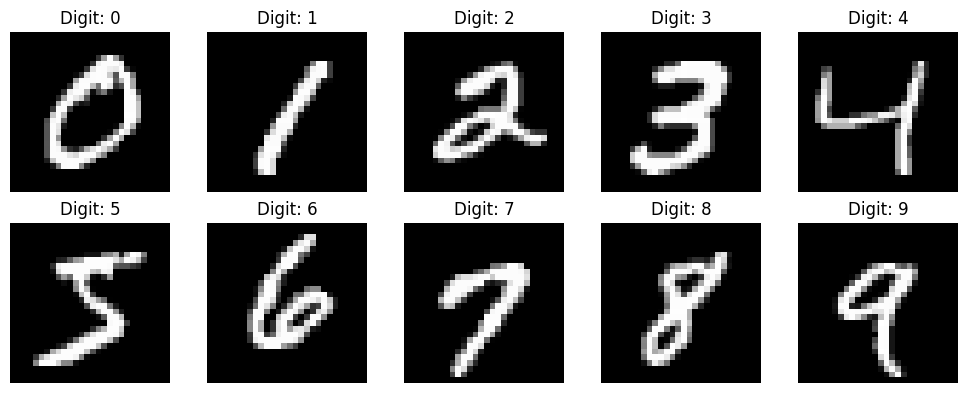

In [ ]:
X_train, X_test, y_train, y_test = load_and_prepare_mnist("/content/drive/MyDrive/AI ML/Data/mnist_dataset.csv")

  3. Training of the Model:

In [ ]:
# Assert that X and y have matching lengths
assert len(X_train) == len(y_train), f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
print("Move forward: Dimension of Feture Matrix X and label vector y matched.")

Move forward: Dimension of Feture Matrix X and label vector y matched.


Iteration 0: Cost = 2.204515
Iteration 100: Cost = 0.607749
Iteration 200: Cost = 0.489718
Iteration 300: Cost = 0.441055
Iteration 400: Cost = 0.412959
Iteration 500: Cost = 0.394083
Iteration 600: Cost = 0.380255
Iteration 700: Cost = 0.369542
Iteration 800: Cost = 0.360912
Iteration 900: Cost = 0.353758


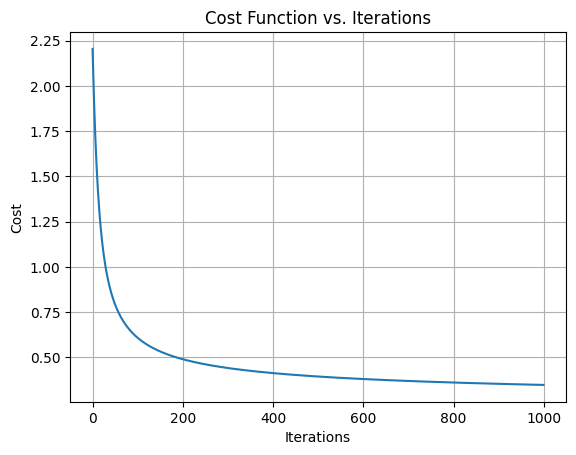

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Check if labels are not one-hot encoded
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)  # Create encoder
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))  # Encode train labels
    y_test = encoder.transform(y_test.reshape(-1, 1))  # Encode test labels

# Get number of features and classes
d = X_train.shape[1]
c = y_train.shape[1]

# Initialize weights and bias
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# Hyperparameters
alpha = 0.1
n_iter = 1000

# Train model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost=True)

# Plot cost vs iterations
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

  4. Evaluating Your Model Performance:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Evaluation Function
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.

    Parameters:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted labels

    Returns:
    tuple: Confusion matrix, precision, recall, F1 score
    """

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute precision, recall, and F1-score
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return cm, precision, recall, f1

How well your model did?


Confusion Matrix:
[[1128    0    5    2    3   10    9    2   13    3]
 [   0 1276    7   11    1    5    1    4   16    1]
 [   1   16 1028   16   19    4   25   25   33    7]
 [   8    5   34 1050    1   52    9    8   31   21]
 [   1    5    7    1 1092    0   11    4    4   51]
 [  22   14   13   45   11  920   13    7   44   15]
 [   7    2    9    1   10   16 1120    2   10    0]
 [   7   26   24    5   15    3    0 1183    7   29]
 [   9   27   15   34    9   34   13    6  998   15]
 [   8    6   10   18   43    9    0   39   10 1051]]
Precision: 0.90
Recall: 0.90
F1-Score: 0.90


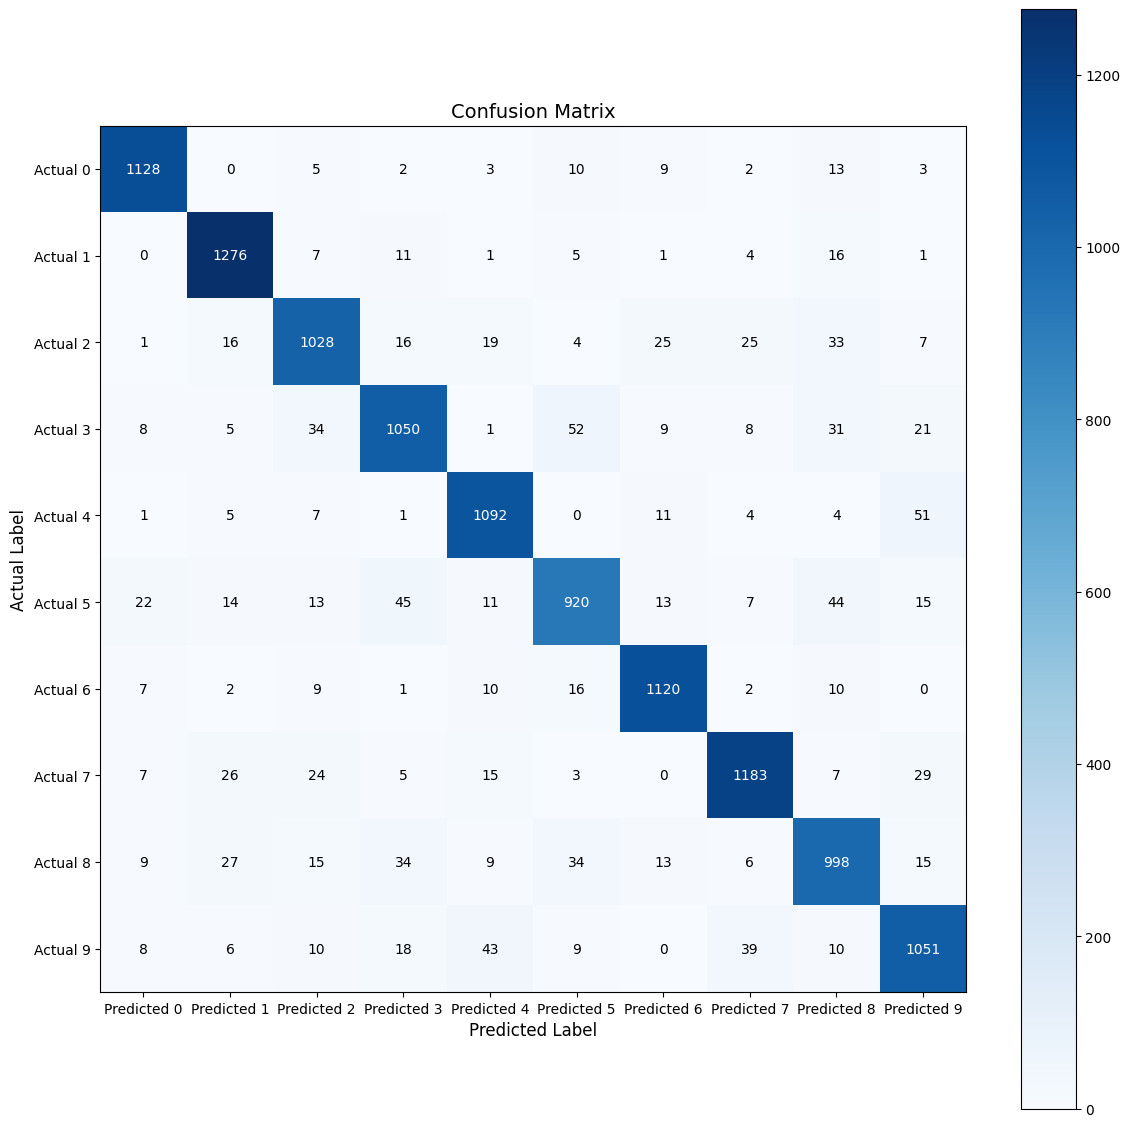

In [ ]:
# Predict on the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# Convert one-hot labels to numeric labels
y_test_labels = np.argmax(y_test, axis=1)

# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print evaluation metrics
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Visualizing the Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')  # Color map

# Dynamic number of classes
num_classes = cm.shape[0]

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))

ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

# Add values inside confusion matrix cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > np.max(cm) / 2 else 'black'
        )

# Labels and title
ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

# Layout and colorbar
plt.tight_layout()
plt.colorbar(cax)

plt.show()

    4.Linear Separability and Logistic Regression.

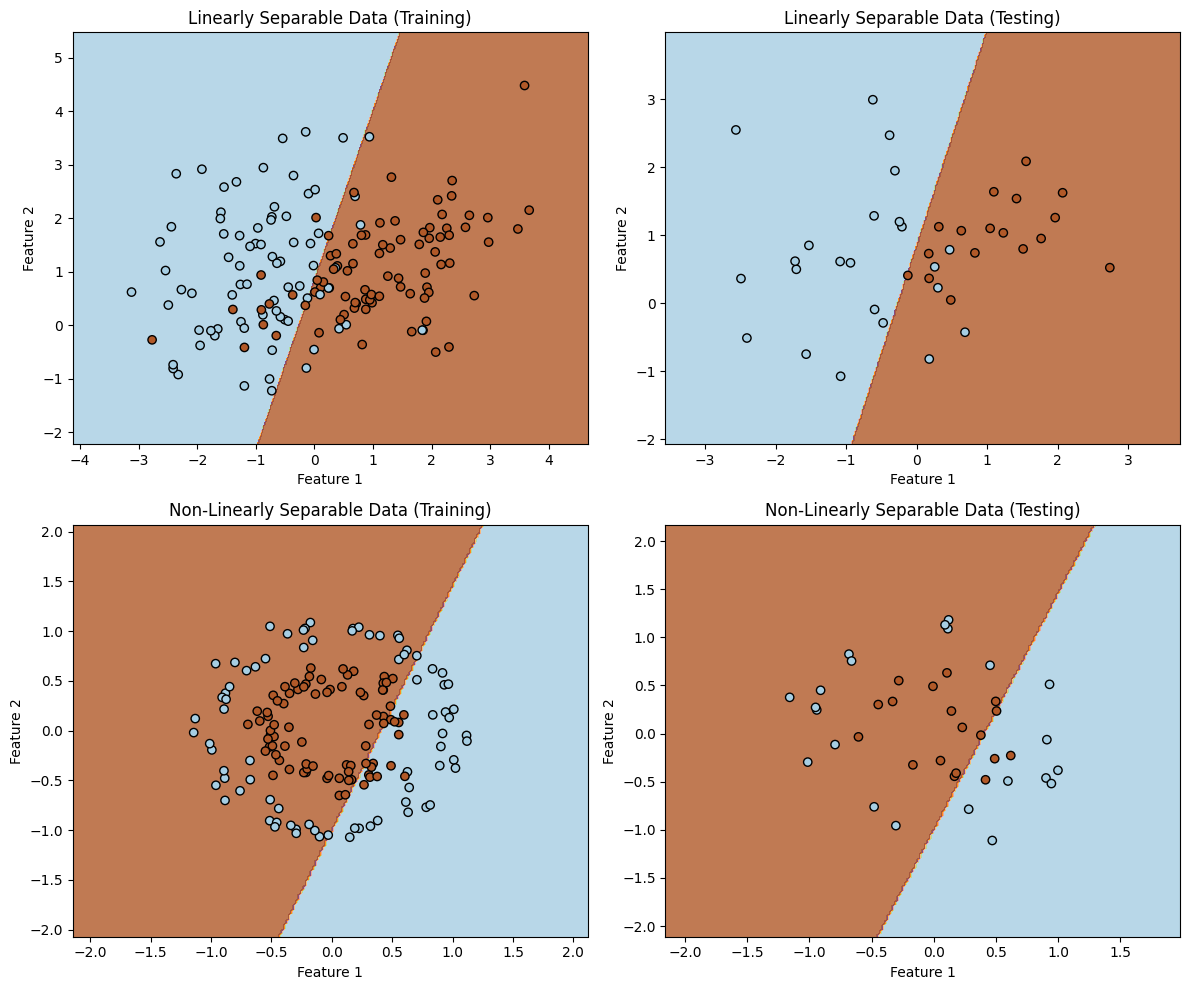

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Set random seed for reproducibility
np.random.seed(42)

# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Split the data into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on linearly separable data
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# Generate non-linearly separable dataset (circles)
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)

# Split the data into training and testing sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on non-linearly separable data
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# Plot decision boundaries for linearly and non-linearly separable data
def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot decision boundary for linearly separable data (Training)
plot_decision_boundary(
    axes[0, 0],
    logistic_model_linear_separable,
    X_train_linear,
    y_train_linear,
    'Linearly Separable Data (Training)'
)

# Plot decision boundary for linearly separable data (Testing)
plot_decision_boundary(
    axes[0, 1],
    logistic_model_linear_separable,
    X_test_linear,
    y_test_linear,
    'Linearly Separable Data (Testing)'
)

# Plot decision boundary for non-linearly separable data (Training)
plot_decision_boundary(
    axes[1, 0],
    logistic_model_non_linear_separable,
    X_train_non_linear,
    y_train_non_linear,
    'Non-Linearly Separable Data (Training)'
)

# Plot decision boundary for non-linearly separable data (Testing)
plot_decision_boundary(
    axes[1, 1],
    logistic_model_non_linear_separable,
    X_test_non_linear,
    y_test_non_linear,
    'Non-Linearly Separable Data (Testing)'
)

plt.tight_layout()

# Save the plots as PNG files
plt.savefig('decision_boundaries.png')

plt.show()

## Answers

### Q1: Is extracting pixel values sufficient for effective feature extraction?
(Ref: load_and_prepare_mnist, plot_sample_images)

Extracting pixel values is a simple way to represent images and it works for basic models like softmax regression. But it is not fully sufficient because it does not capture patterns like shapes, edges, or relationships between pixels. So for more complex tasks, better feature extraction methods are needed.


### Q2: Provide an interpretation of the output based on your understanding
(Ref: logistic regression decision boundary plots)

From the output, we can see that logistic regression works well when the data is linearly separable because it can draw a clear boundary between classes. But for non-linear data, the model does not perform well since it can only create a straight line boundary. This shows that logistic regression is limited to linear problems.


### Q3: Describe any challenges you faced while implementing the code above
(Ref: softmax, loss_softmax, gradient_descent_softmax)

While implementing the code, I faced some difficulties understanding the softmax function and cross-entropy loss. I also had some issues with matrix dimensions and errors during gradient calculation. Debugging and making sure the model trains properly was also a bit challenging.
